Anomalous glacier:   
1. for grid cell scale: (94E-94.4E,30N-30.5N), (94E-94.5E, 30.5-31N) for 2000-2011.   


### Elevation change drived by altimeter 


In [46]:
import xarray as xr
import numpy as np
import rasterio as rio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
from utils.ransac_fitting import ransac_fitting


In [47]:
path_ele_change_fused = 'data/ele-change-result/ele_change_fused_tiles_sub.nc'
path_rgi_setp = 'data/land-cover/rgi60/rgi60_setp.shp'


In [48]:
ele_change_fused_xr = xr.open_dataset(path_ele_change_fused)


Grid cell (94E-94.5E, 30-30.5N) during 2000-2011


In [49]:
### fused elevation change data (no valid icesat data)
ele_change_fused_xr.ele_change_tiles
years_sel = ['2000','2001','2002','2003','2004','2005','2006','2007','2008','2009','2010','2011']
tile_sel = 'tile_300_940'
ele_change_sel = ele_change_fused_xr.ele_change_tiles.sel(tiles_id=tile_sel , years=years_sel)
ele_change_sel
ele_change_sel_filtered, ele_change_sel_fitting, ele_change_sel_rate = ransac_fitting(x=np.arange(len(ele_change_sel.years)), y=ele_change_sel, thre_mask=50)
print(ele_change_sel_rate)


1.4038721213976708


Text(0.5, 0, 'Year')

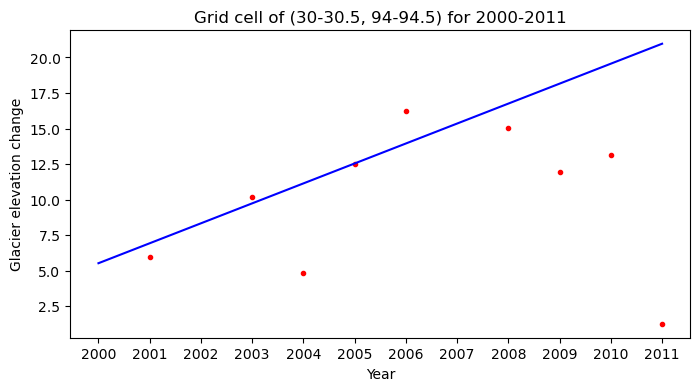

In [50]:
### the location of (30.25, 94.25)
fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.scatter(ele_change_sel.years, ele_change_sel.values, marker = '.', color='red')
plt.plot(ele_change_sel.years, ele_change_sel_fitting, '-b', label='ele_change_rate')
ax.set_title('Grid cell of (30-30.5, 94-94.5) for 2000-2011')
ax.set_ylabel('Glacier elevation change')
ax.set_xlabel('Year')


In [60]:
### grid cell of the hugonnet data (image reprojection by using utils/reproj_img.py)
path_Hugonnet_wgs84 = 'data/ele-change-dset/N30E094_2000-01-01_2010-01-01_dhdt_wgs84.tif'
minx, maxx = 94, 94.5
miny, maxy = 30, 30.5
region = box(minx, miny, maxx, maxy)
rgi60_setp_gpd = gpd.read_file(path_rgi_setp)
dset_hugonnet = rio.open(path_Hugonnet_wgs84)
rgi60_05grid = rgi60_setp_gpd.clip(region)
dset_hugonnet_05grid, _ = mask(dset_hugonnet, shapes=rgi60_05grid['geometry'], crop=True)
dset_hugonnet_05grid[dset_hugonnet_05grid==-9999] = np.nan
dset_hugonnet_05grid[abs(dset_hugonnet_05grid)>10] = np.nan
print(np.nanmean(dset_hugonnet_05grid))


-0.4767384


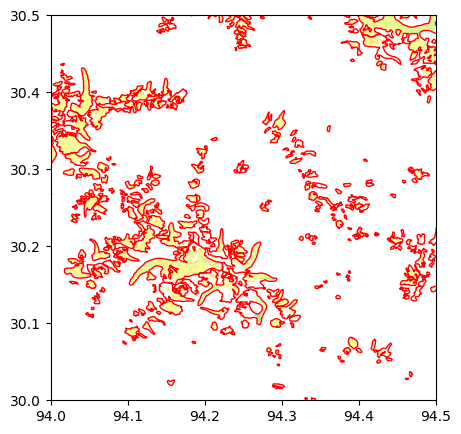

In [7]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
rgi60_setp_gpd.plot(ax=ax, facecolor='none', edgecolor='red')
plt.imshow(dset_hugonnet_05grid[0], cmap='terrain', extent=[minx, maxx, miny, maxy])


Grid cell (94E-94.5E, 30.5-31N) during 2000-2011


In [40]:
### Fused elevation change data (no valid icesat data)
ele_change_fused_xr.ele_change_tiles
years_sel = ['2000','2001','2002','2003','2004','2005','2006','2007','2008','2009','2010','2011']
tile_sel = 'tile_305_940'
ele_change_sel = ele_change_fused_xr.ele_change_tiles.sel(tiles_id=tile_sel , years=years_sel)
ele_change_sel
ele_change_sel_filtered, ele_change_sel_fitting, ele_change_sel_rate = ransac_fitting(x=np.arange(len(ele_change_sel.years)), y=ele_change_sel, thre_mask=50)
print(ele_change_sel_rate)


0.18057962301122474


Text(0.5, 0, 'Year')

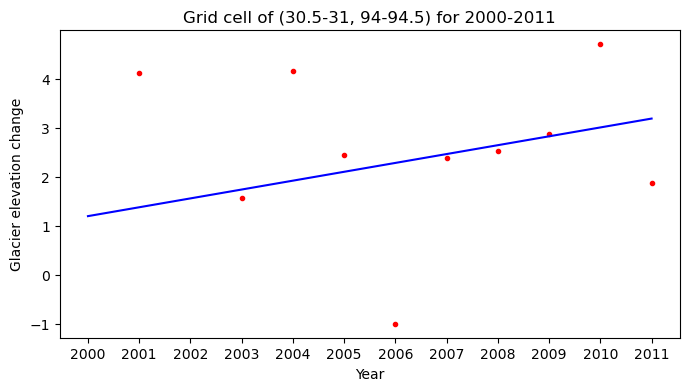

In [42]:
fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.scatter(ele_change_sel.years, ele_change_sel.values, marker = '.', color='red')
plt.plot(ele_change_sel.years, ele_change_sel_fitting, '-b', label='ele_change_rate')
ax.set_title('Grid cell of (30.5-31, 94-94.5) for 2000-2011')
ax.set_ylabel('Glacier elevation change')
ax.set_xlabel('Year')


In [59]:
### grid cell of the hugonnet data (image reprojection by using utils/reproj_img.py)
path_Hugonnet_wgs84 = 'data/ele-change-dset/N30E094_2000-01-01_2010-01-01_dhdt_wgs84.tif'
minx, maxx = 94, 94.5
miny, maxy = 30.5, 31
region = box(minx, miny, maxx, maxy)
rgi60_setp_gpd = gpd.read_file(path_rgi_setp)
dset_hugonnet = rio.open(path_Hugonnet_wgs84)
rgi60_05grid = rgi60_setp_gpd.clip(region)
dset_hugonnet_05grid, _ = mask(dset_hugonnet, shapes=rgi60_05grid['geometry'], crop=True)
dset_hugonnet_05grid[dset_hugonnet_05grid==-9999] = np.nan
dset_hugonnet_05grid[abs(dset_hugonnet_05grid)>10] = np.nan
print(np.nanmean(dset_hugonnet_05grid))


-0.4266859


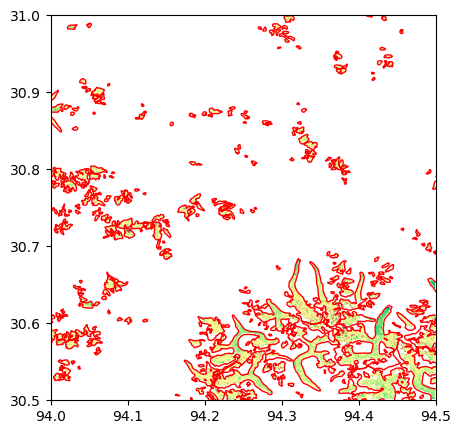

In [11]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
rgi60_setp_gpd.plot(ax=ax, facecolor='none', edgecolor='red')
plt.imshow(dset_hugonnet_05grid[0], cmap='terrain', extent=[minx, maxx, miny, maxy])
